언어 모델을 위한 피드포워드 신경망 구현 및 학습

In [1]:
import warnings
from tqdm import tqdm

warnings.simplefilter('ignore')
import time
from collections import OrderedDict

import re

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import string
import time
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
from nltk.tokenize import word_tokenize

from sklearn.manifold import TSNE

def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Gaten\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Gaten\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
song= """We are no strangers to love
You know the rules and so do I
A full commitments what Im thinking of
You wouldnt get this from any other guy
I just wanna tell you how Im feeling
Gotta make you understand
Never gonna give you up
Never gonna let you down
Never gonna run around and desert you
Never gonna make you cry
Never gonna say goodbye
Never gonna tell a lie and hurt you
Weve known each other for so long
Your hearts been aching but youre too shy to say it
Inside we both know whats been going on
We know the game and were gonna play it
And if you ask me how Im feeling
Dont tell me youre too blind to see
Never gonna give you up
Never gonna let you down
Never gonna run around and desert you
Never gonna make you cry
Never gonna say goodbye
Never gonna tell a lie and hurt you
Never gonna give you up
Never gonna let you down
Never gonna run around and desert you
Never gonna make you cry
Never gonna say goodbye
Never gonna tell a lie and hurt you
Weve known each other for so long
Your hearts been aching but youre too shy to say it
Inside we both know whats been going on
We know the game and were gonna play it
I just wanna tell you how Im feeling
Gotta make you understand
Never gonna give you up
Never gonna let you down
Never gonna run around and desert you
Never gonna make you cry
Never gonna say goodbye
Never gonna tell a lie and hurt you
Never gonna give you up
Never gonna let you down
Never gonna run around and desert you
Never gonna make you cry
Never gonna say goodbye
Never gonna tell a lie and hurt you
Never gonna give you up
Never gonna let you down
Never gonna run around and desert you
Never gonna make you cry
Never gonna say goodbye
Never gonna tell a lie and hurt you"""

In [3]:
tokenizer = get_tokenizer("basic_english")
tokens=tokenizer(song)

In [4]:
def preprocess_string(s):
    """
    Preprocesses a given string by performing the following steps:
    
    1. Removes all non-word characters (excluding letters and numbers).
    2. Removes all whitespace characters.
    3. Removes all numeric digits.

    Parameters:
    s (str): The input string to be cleaned.

    Returns:
    str: The processed string with only alphabetic characters, no spaces, and no digits.
    """

    # Remove all non-word characters (everything except letters and numbers)
    # \w matches any word character (letters, numbers, and underscores)
    # \s matches any whitespace characters
    # ^ inside [] negates the selection, so [^\w\s] matches anything that's NOT a word character or whitespace.
    s = re.sub(r"[^\w\s]", '', s)

    # Remove all whitespace characters (spaces, tabs, newlines)
    # \s+ matches one or more whitespace characters.
    s = re.sub(r"\s+", '', s)

    # Remove all digits (0-9)
    # \d matches any digit character.
    s = re.sub(r"\d", '', s)

    return s

In [5]:
def preprocess(words):
    """
    Preprocesses a given text by tokenizing it, cleaning individual words, and 
    converting them to lowercase while removing empty or punctuation tokens.

    Steps:
    1. Tokenization: Splits the input text into individual word tokens.
    2. Cleaning: Applies `preprocess_string()` to remove non-word characters, 
       spaces, and digits from each token.
    3. Normalization: Converts all tokens to lowercase.
    4. Filtering: Removes empty strings and punctuation tokens.

    Parameters:
    words (str): The input text to be tokenized and preprocessed.

    Returns:
    list: A list of cleaned, lowercase tokens.
    """

    # Tokenize the input text into words
    tokens = word_tokenize(words)

    # Apply preprocessing to each token (removes unwanted characters)
    tokens = [preprocess_string(w) for w in tokens]

    # Convert tokens to lowercase and remove empty strings or punctuation
    return [w.lower() for w in tokens if len(w) != 0 and w not in string.punctuation]

# Example usage:
tokens = preprocess(song)  # Preprocess the text in 'song'

In [6]:
def tokenizetext(song):
    """
    Tokenizes the input text (song) and builds a vocabulary from the tokens.

    Steps:
    1. Tokenization: The function splits the input text into words and applies 
       a tokenizer function to each word.
    2. Vocabulary Building: Constructs a vocabulary from the tokenized words,
       including a special "<unk>" token to handle out-of-vocabulary words.
    3. Default Indexing: Sets the default index for unknown words, ensuring 
       that any unseen tokens are mapped to "<unk>".

    Parameters:
    song (str): The input text (song lyrics) to be tokenized and processed.

    Returns:
    vocab (Vocab): A vocabulary object mapping tokens to their corresponding indices.
    """

    # Tokenize the text
    # Split the input text into words and apply the tokenizer function to each word.
    # The 'map' function ensures that each word is tokenized properly.
    tokenized_song = map(tokenizer, song.split())

    # Build vocabulary from tokenized text
    # The function `build_vocab_from_iterator` constructs a vocabulary by iterating 
    # over the tokenized words. The special token "<unk>" is added to handle words 
    # that are not present in the vocabulary.
    vocab = build_vocab_from_iterator(tokenized_song, specials=["<unk>"])

    # Set the default index for unknown words
    # The default index is set to the index of "<unk>" so that any word not found 
    # in the vocabulary is mapped to this token, preventing errors during lookup.
    vocab.set_default_index(vocab["<unk>"])

    return vocab


In [7]:
vocab=tokenizetext(song)
vocab(tokens[0:10])

[21, 58, 70, 74, 25, 69, 2, 20, 31, 72]

In [8]:
tokens[0:10]

['we', 'are', 'no', 'strangers', 'to', 'love', 'you', 'know', 'the', 'rules']

In [9]:
text_pipeline = lambda x: vocab(tokenizer(x))
text_pipeline(song)[0:10]

[21, 58, 70, 74, 25, 69, 2, 20, 31, 72]

In [10]:
index_to_token = vocab.get_itos()
index_to_token[58]

'are'

In [11]:
def genembedding(vocab):
    """
    Generates an embedding layer for the given vocabulary.

    The embedding layer transforms words into dense vector representations, 
    allowing the model to learn semantic relationships between words.

    Parameters:
    vocab (Vocab): The vocabulary object containing unique words and their indices.

    Returns:
    nn.Embedding: A PyTorch embedding layer with a specified embedding dimension.
    """

    # Define the embedding dimension (size of word vectors)
    embedding_dim = 20  # Each word will be represented as a 20-dimensional vector

    # Get the vocabulary size (number of unique words in the vocabulary)
    vocab_size = len(vocab)

    # Create an embedding layer
    # The nn.Embedding module maps word indices to dense vector representations.
    # It takes vocab_size as the number of words and embedding_dim as the vector size.
    embeddings = nn.Embedding(vocab_size, embedding_dim)

    return embeddings

In [12]:
embeddings=genembedding(vocab)
for n in range(2): 
    embedding=embeddings(torch.tensor(n))
    print("word",index_to_token[n])
    print("index",n)
    print( "embedding", embedding)
    print("embedding shape", embedding.shape)

word <unk>
index 0
embedding tensor([ 1.5427,  1.5466, -0.3395,  0.1420,  0.3701, -1.8833, -0.6657,  0.7197,
        -0.3406,  1.2039,  0.6107, -0.2265, -2.3592,  0.3785,  0.9057, -0.4020,
         2.3591, -0.3680,  0.3084,  1.1092], grad_fn=<EmbeddingBackward0>)
embedding shape torch.Size([20])
word gonna
index 1
embedding tensor([ 0.0758, -0.9857,  1.5452,  1.6425,  0.4373, -0.4482,  0.0259, -1.2508,
        -1.0837,  1.0838,  0.8270,  2.1999, -0.2236, -0.3042,  1.3655,  1.4817,
        -0.0839,  0.9189,  0.8168, -0.3557], grad_fn=<EmbeddingBackward0>)
embedding shape torch.Size([20])


In [13]:
# Define the context size for generating n-grams
CONTEXT_SIZE = 2  # The number of previous words used to predict the next word

def genngrams(tokens):
    """
    Generates n-grams from a list of tokens, where each n-gram consists of a 
    context (previous words) and a target (next word).

    The function constructs a list of tuples where:
    - The first element is a list of `CONTEXT_SIZE` previous words.
    - The second element is the target word that follows the context.

    Parameters:
    tokens (list): A list of preprocessed word tokens.

    Returns:
    list: A list of tuples representing n-grams.
          Each tuple contains (context_words, target_word).
    """

    # Generate n-grams
    # Iterate through the tokens starting from index CONTEXT_SIZE to the end
    # For each token at position 'i', extract the previous CONTEXT_SIZE words as context
    ngrams = [
        (
            [tokens[i - j - 1] for j in range(CONTEXT_SIZE)],  # Context words (previous words)
            tokens[i]  # Target word (the word to predict)
        )
        for i in range(CONTEXT_SIZE, len(tokens))
    ]

    return ngrams


In [14]:
ngrams=genngrams(tokens)
context, target=ngrams[0]
print("context",context,"target",target)
print("context index",vocab(context),"target index",vocab([target]))

context ['are', 'we'] target no
context index [58, 21] target index [70]


In [15]:
embedding_dim=20
linear = nn.Linear(embedding_dim*CONTEXT_SIZE,128)

In [16]:
embeddings=genembedding(vocab)
my_embeddings=embeddings(torch.tensor(vocab(context)))
my_embeddings.shape

torch.Size([2, 20])

In [17]:
my_embeddings=my_embeddings.reshape(1,-1)
my_embeddings.shape

torch.Size([1, 40])

In [18]:
linear(my_embeddings)

tensor([[ 1.0568,  0.8494, -0.9772, -0.3938, -0.5196,  0.7144, -0.0804, -0.1853,
         -0.0609,  0.1475, -0.9981, -0.1000,  0.2420,  1.3980, -0.5284,  0.8504,
         -0.4531,  0.5890, -0.0320, -0.1344, -0.2847,  1.5787,  0.0527, -0.4761,
         -0.9588,  0.9440,  0.3909,  0.0396,  0.7706, -0.2648, -0.2457, -1.2910,
          0.3639,  0.2002, -0.1742,  0.4466,  0.0696,  0.1640, -0.5514,  1.1357,
          0.5825,  1.2171, -0.4817,  0.0165,  0.2632, -0.9473,  0.5795, -1.1727,
          0.6023, -1.0238,  0.7661, -0.5153,  0.1759, -1.0224,  0.1108,  0.2912,
          0.3973, -0.2919, -0.0430,  0.9230, -0.9434, -0.6881, -0.2672, -0.4328,
          0.2479,  0.0277, -0.0878,  0.3601, -0.0236, -0.3151, -0.6553, -0.6931,
          0.1538,  0.7461, -0.3643,  0.2464,  0.3790,  0.7876,  0.4626,  0.6957,
         -0.8547,  0.0422,  0.5939, -0.2308, -0.8961, -0.1238, -0.6371,  0.7682,
         -0.9814, -0.2232, -0.2453, -0.9005, -0.2815, -0.9381, -0.4396,  0.0867,
          0.3347, -0.6772, -

In [19]:
from torch.utils.data import DataLoader  # Importing DataLoader for batch processing
import torch  # Importing PyTorch

# Set the device to GPU if available; otherwise, use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define hyperparameters
CONTEXT_SIZE = 3   # Number of previous words used as context for prediction
BATCH_SIZE = 10    # Number of samples per training batch
EMBEDDING_DIM = 10 # Dimension of word embeddings

def collate_batch(batch):
    """
    Processes a batch of text data into input (context) and output (target) tensors
    for training a language model.

    The function extracts:
    - `context`: A list of word indices representing the context words for each target word.
    - `target`: A list of word indices representing the target word to predict.

    Parameters:
    batch (list): A list of tokenized words (strings).

    Returns:
    tuple: Two PyTorch tensors: (context_tensor, target_tensor)
           - context_tensor: Tensor of shape (batch_size - CONTEXT_SIZE, CONTEXT_SIZE),
             containing the word indices of context words.
           - target_tensor: Tensor of shape (batch_size - CONTEXT_SIZE,),
             containing the word indices of target words.
    """

    batch_size = len(batch)  # Get the size of the batch
    context, target = [], [] # Initialize lists for context and target words

    # Loop through the batch, ensuring enough previous words exist for context
    for i in range(CONTEXT_SIZE, batch_size):
        # Convert the target word to its index using the vocabulary
        target.append(vocab([batch[i]]))

        # Convert the previous CONTEXT_SIZE words to indices using the vocabulary
        context.append(vocab([batch[i - j - 1] for j in range(CONTEXT_SIZE)]))

    # Convert lists to PyTorch tensors and move them to the appropriate device (CPU/GPU)
    return torch.tensor(context).to(device), torch.tensor(target).to(device).reshape(-1)


In [20]:
Padding=BATCH_SIZE-len(tokens)%BATCH_SIZE
tokens_pad=tokens+tokens[0:Padding]

dataloader = DataLoader(
     tokens_pad, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch
)

In [21]:
class NGramLanguageModeler(nn.Module):
    """
    A neural network-based n-gram language model that predicts the next word 
    given a sequence of context words.

    This model consists of:
    - An embedding layer that converts word indices into dense vector representations.
    - A fully connected hidden layer with ReLU activation.
    - An output layer that predicts the probability distribution over the vocabulary.

    Parameters:
    vocab_size (int): The number of unique words in the vocabulary.
    embedding_dim (int): The size of the word embeddings (vector representation of words).
    context_size (int): The number of previous words used as context to predict the next word.
    """

    def __init__(self, vocab_size, embedding_dim, context_size):
        super(NGramLanguageModeler, self).__init__()

        # Store context size and embedding dimension
        self.context_size = context_size
        self.embedding_dim = embedding_dim

        # Embedding layer: Maps word indices to dense vectors
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)

        # Fully connected hidden layer: Maps the concatenated embeddings to a 128-dimensional space
        self.linear1 = nn.Linear(context_size * embedding_dim, 128)

        # Output layer: Maps the hidden layer output to vocabulary size (probability distribution over words)
        self.linear2 = nn.Linear(128, vocab_size)

    def forward(self, inputs):
        """
        Forward pass of the model.

        Parameters:
        inputs (Tensor): A tensor of shape (batch_size, context_size) containing word indices.

        Returns:
        Tensor: A tensor of shape (batch_size, vocab_size) representing predicted probabilities for the next word.
        """

        # Convert input word indices into dense vectors using the embedding layer
        embeds = self.embeddings(inputs)  # Shape: (batch_size, context_size, embedding_dim)

        # Reshape the embeddings into a single vector per input sample
        embeds = torch.reshape(embeds, (-1, self.context_size * self.embedding_dim))  
        # New shape: (batch_size, context_size * embedding_dim)

        # Apply first fully connected layer with ReLU activation
        out = F.relu(self.linear1(embeds))  # Shape: (batch_size, 128)

        # Apply second fully connected layer to generate vocabulary-size logits
        out = self.linear2(out)  # Shape: (batch_size, vocab_size)

        return out


In [22]:
model = NGramLanguageModeler(len(vocab), EMBEDDING_DIM, CONTEXT_SIZE).to(device)

In [23]:
context, target=next(iter(dataloader))
print(context, target)
out=model(context)

tensor([[70, 58, 21],
        [74, 70, 58],
        [25, 74, 70],
        [69, 25, 74],
        [ 2, 69, 25],
        [20,  2, 69],
        [31, 20,  2]]) tensor([74, 25, 69,  2, 20, 31, 72])


In [24]:
out.shape

torch.Size([7, 79])

In [26]:
predicted_index = torch.argmax(out,1)
predicted_index

tensor([ 8,  8,  8,  7, 63, 74, 75])

In [27]:
[index_to_token[i.item()] for i in  predicted_index]

['a', 'a', 'a', 'say', 'dont', 'strangers', 'thinking']

In [28]:
def write_song(model, my_song, number_of_words=100):
    """
    Generates text using a trained n-gram language model.

    Given an initial text (`my_song`), the function generates additional words by 
    predicting the next word iteratively based on the trained model.

    Parameters:
    model (nn.Module): The trained n-gram language model.
    my_song (str): The initial seed text to start generating words.
    number_of_words (int): The number of words to generate (default: 100).

    Returns:
    str: The generated song lyrics as a string.
    """

    # Get the mapping from index to word for decoding predictions
    index_to_token = vocab.get_itos()

    # Loop to generate the desired number of words
    for i in range(number_of_words):

        with torch.no_grad():  # Disable gradient computation for inference
            
            # Prepare the input context by extracting the last CONTEXT_SIZE words from tokens
            context = torch.tensor(
                vocab([tokens[i - j - 1] for j in range(CONTEXT_SIZE)])
            ).to(device)  # Move to CPU/GPU as required
            
            # Predict the next word by selecting the word with the highest probability
            word_idx = torch.argmax(model(context))  # Get index of the most likely next word
            
            # Append the predicted word to the generated text
            my_song += " " + index_to_token[word_idx.detach().item()]

    return my_song  # Return the generated lyrics


In [29]:
def pickrandomline(song):
    """
    Selects a random line from the given song text.

    This function splits the song into separate lines and randomly picks one of them.

    Parameters:
    song (str): The song lyrics as a multi-line string.

    Returns:
    str: A randomly selected line from the song.
    """
    
    # Split the song into individual lines
    lines = song.split("\n")  
    
    # Randomly select a line and remove leading/trailing whitespace
    selected_line = random.choice(lines).strip()
    
    return selected_line  # Return the randomly selected line

# Example usage:
selected_line = pickrandomline(song)  # Pick a random line from the song

# Generate a new song starting with the selected line
generated_song = write_song(model, selected_line)

# Print the generated lyrics
print(generated_song)


Dont tell me youre too blind to see a game going a a a say dont strangers thinking your game me your this know to know cry both know to each to the to know ask dont know your know your know any know a any game get know know know around know ask your know know me to game your get the know know ask your too the strangers me to know game your know know a weve know your the know know a your any know a know to a game any each say know to to other a to a your me gotta to gotta


In [30]:
criterion = torch.nn.CrossEntropyLoss()

In [31]:
def train(dataloader, model,song,number_of_epochs=100, show=10):
    """
    Args:
        dataloader (DataLoader): DataLoader containing training data.
        model (nn.Module): Neural network model to be trained.
        number_of_epochs (int, optional): Number of epochs for training. Default is 100.
        show (int, optional): Interval for displaying progress. Default is 10.

    Returns:
        list: List containing loss values for each epoch.
    """

    MY_LOSS = []  # List to store loss values for each epoch

    # Iterate over the specified number of epochs
    for epoch in tqdm(range(number_of_epochs)):
        total_loss = 0  # Initialize total loss for the current epoch
        my_song = ""    # Initialize a string to store the generated song

        # Iterate over batches in the dataloader
        for context, target in dataloader:
            model.zero_grad()          # Zero the gradients to avoid accumulation
            predicted = model(context)  # Forward pass through the model to get predictions
            loss = criterion(predicted, target.reshape(-1))  # Calculate the loss
            total_loss += loss.item()   # Accumulate the loss

            loss.backward()    # Backpropagation to compute gradients
            optimizer.step()   # Update model parameters using the optimizer

        # Display progress and generate song at specified intervals
        if epoch % show == 0:
            selected_line=pickrandomline(song)
            my_song += write_song(model, selected_line)    # Generate song using the model

            print("Generated Song:")
            print("\n")
            print(my_song)

        MY_LOSS.append(total_loss/len(dataloader))  # Append the total loss for the epoch to MY_LOSS list

    return MY_LOSS  # Return the list of  mean loss values for each epoch

In [34]:
my_loss_list=[]

# Define the context size for the n-gram model
CONTEXT_SIZE = 2

# Create an instance of the NGramLanguageModeler class with specified parameters
model_2 = NGramLanguageModeler(len(vocab), EMBEDDING_DIM, CONTEXT_SIZE).to(device)

# Define the optimizer for training the model, using stochastic gradient descent (SGD)
optimizer = optim.SGD(model_2.parameters(), lr=0.01)

# Set up a learning rate scheduler using StepLR to adjust the learning rate during training
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1.0, gamma=0.1)

In [35]:
my_loss=train(dataloader,model_2,song)

  6%|▌         | 6/100 [00:00<00:01, 52.62it/s]

Generated Song:


Never gonna let you down <unk> <unk> you <unk> <unk> <unk> <unk> tell <unk> <unk> you <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> you <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> you you <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> you you <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> this <unk> this <unk> <unk> <unk> just <unk> <unk>
Generated Song:


Gotta make you understand never <unk> never <unk> <unk> never you <unk> <unk> never <unk> <unk> <unk> you never never you <unk> <unk> you never <unk> never <unk> you <unk> you never <unk> you you you <unk> tell you you never never never <unk> tell you <unk> never <unk> <unk> tell you never <unk> <unk> <unk> tell you <unk> never <unk> <unk> tell you never 

 34%|███▍      | 34/100 [00:00<00:01, 65.15it/s]

Generated Song:


Weve known each other for so long never <unk> never never <unk> never you <unk> never never <unk> <unk> <unk> you never never you <unk> <unk> never never <unk> never never you <unk> you never and hurt you you <unk> tell you you never never and <unk> tell you <unk> never <unk> <unk> tell you never never <unk> <unk> tell you <unk> never <unk> <unk> tell you and <unk> you never <unk> <unk> tell you <unk> <unk> <unk> <unk> tell goodbye never <unk> <unk> tell you you and hurt you never never <unk> <unk> and hurt <unk> you you you and you <unk> never you never never
Generated Song:


Inside we both know whats been going on never <unk> never never to and you <unk> never never <unk> <unk> <unk> you never never you and <unk> never never <unk> never never you <unk> you never and hurt you you <unk> tell you you never feeling and <unk> tell you <unk> never <unk> <unk> tell you never never <unk> <unk> tell you down never <unk> <unk> tell you and desert you never <unk> <unk> tell y

 49%|████▉     | 49/100 [00:00<00:00, 66.05it/s]

...

 70%|███████   | 70/100 [00:01<00:00, 66.20it/s]

Generated Song:


Gotta make you understand never <unk> no never to never you know the game know and <unk> you never desert you and im feeling never <unk> know never you from you other and hurt how <unk> <unk> tell you how never feeling <unk> <unk> tell you understand never <unk> <unk> tell you never never <unk> <unk> tell you down never <unk> <unk> tell you and desert you never <unk> <unk> tell you understand never <unk> <unk> tell goodbye never <unk> <unk> tell you desert and hurt you never known each other for hurt <unk> you to been aching but youre too shy to never
Generated Song:


Never gonna give you up never <unk> no strangers to love you know the game know and <unk> you never full you and im feeling never <unk> know never you from any other and hurt how <unk> <unk> tell you how im feeling dont <unk> tell you understand never <unk> <unk> tell you never never <unk> <unk> tell you down never <unk> <unk> tell you and desert you never <unk> <unk> tell you understand never <unk> <un

 91%|█████████ | 91/100 [00:01<00:00, 65.38it/s]

Generated Song:


Never gonna run around and desert you never <unk> no strangers to love you know the game know and <unk> i a full you and im feeling <unk> <unk> know never you from any other and hurt how <unk> <unk> tell you how im feeling dont <unk> tell you understand never <unk> <unk> tell you never never <unk> <unk> tell you down never <unk> <unk> tell you and desert you never <unk> <unk> tell you understand never <unk> <unk> tell goodbye never <unk> <unk> tell you lie and hurt you never known each other for so long you hearts been aching but youre too shy to never
Generated Song:


I just wanna tell you how Im feeling never <unk> no strangers to love you know the game know and <unk> i a full you and im feeling <unk> <unk> understand never you from any other and hurt how <unk> <unk> tell you how im feeling dont <unk> tell you understand never <unk> <unk> tell you never never <unk> <unk> tell you down never <unk> <unk> tell you and desert you never <unk> <unk> tell you understand n

100%|██████████| 100/100 [00:01<00:00, 65.23it/s]


In [36]:
save_path = '2gram.pth'
torch.save(model_2.state_dict(), save_path)
my_loss_list.append(my_loss)

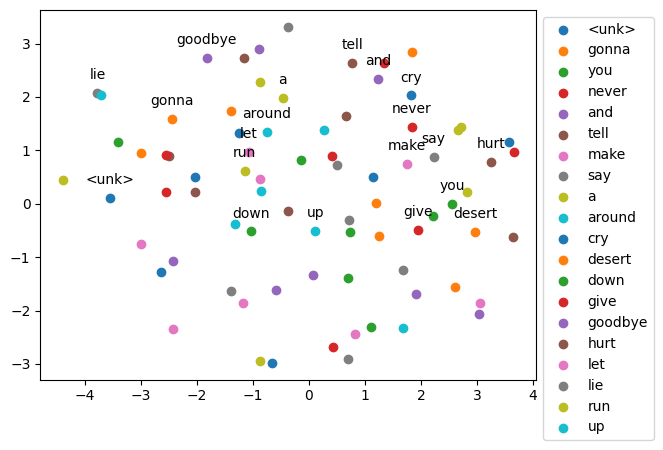

In [37]:
X = model_2.embeddings.weight.cpu().detach().numpy()
tsne = TSNE(n_components=2, random_state=42)
X_2d = tsne.fit_transform(X)

labels = []

for j in range(len(X_2d)):
    if j < 20:
        plt.scatter(X_2d[j, 0], X_2d[j, 1], label=index_to_token[j])
        labels.append(index_to_token[j])
        # Add words as annotations
        plt.annotate(index_to_token[j],
                     (X_2d[j, 0], X_2d[j, 1]),
                     textcoords="offset points",
                     xytext=(0, 10),
                     ha='center')
    else:
        plt.scatter(X_2d[j, 0], X_2d[j, 1])

plt.legend(labels, loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

In [38]:
import numpy as np
print(np.__version__)

1.26.4


In [39]:
CONTEXT_SIZE=4
model_4 = NGramLanguageModeler(len(vocab), EMBEDDING_DIM, CONTEXT_SIZE).to(device)
optimizer = optim.SGD(model_4.parameters(), lr=0.01)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 1.0, gamma=0.1)
my_loss=train(dataloader,model_4,song)

save_path = '4gram.pth'
torch.save(model_4.state_dict(), save_path)

my_loss_list.append(my_loss)

 14%|█▍        | 14/100 [00:00<00:01, 67.38it/s]

Generated Song:


Weve known each other for so long <unk> <unk> <unk> guy you <unk> you <unk> <unk> <unk> any <unk> you <unk> me <unk> <unk> <unk> <unk> you <unk> <unk> <unk> you <unk> any <unk> you <unk> this <unk> <unk> <unk> <unk> shy <unk> <unk> i you <unk> <unk> you <unk> <unk> you <unk> <unk> you shy <unk> <unk> <unk> <unk> you <unk> <unk> <unk> <unk> <unk> you <unk> you you say <unk> <unk> <unk> you <unk> <unk> <unk> <unk> <unk> you never how <unk> <unk> you shy <unk> <unk> you <unk> <unk> <unk> you <unk> <unk> <unk> you a <unk> <unk> guy <unk> <unk> <unk> <unk> game
Generated Song:


Never gonna say goodbye never <unk> never <unk> you you you never <unk> <unk> never never <unk> <unk> never <unk> <unk> never <unk> you never <unk> never never never never <unk> never <unk> <unk> <unk> <unk> <unk> <unk> you never never you never <unk> <unk> you never never <unk> <unk> give you never never <unk> <unk> tell you never never <unk> <unk> tell you never never you never <unk> <unk> make y

 29%|██▉       | 29/100 [00:00<00:01, 69.31it/s]

Generated Song:


Your hearts been aching but youre too shy to say it never <unk> never <unk> you you you never <unk> <unk> never never <unk> you never never <unk> never you goodbye never <unk> let never never never <unk> never <unk> <unk> <unk> <unk> <unk> tell you down never feeling never <unk> <unk> you never never <unk> <unk> give you never never <unk> <unk> let you down never <unk> <unk> give you down never you never <unk> <unk> make you never never <unk> <unk> say you never <unk> <unk> tell you never never you you never <unk> <unk> other you <unk> <unk> <unk> you never never <unk> down never you <unk> <unk>
Generated Song:


A full commitments what Im thinking of never you never <unk> to you you never <unk> <unk> never never <unk> you a never <unk> never you goodbye never <unk> let never never you <unk> never you <unk> <unk> <unk> <unk> tell you down im feeling <unk> <unk> <unk> you down never <unk> <unk> give you down never <unk> <unk> let you down never <unk> <unk> give you dow

 51%|█████     | 51/100 [00:00<00:00, 68.48it/s]

...

 73%|███████▎  | 73/100 [00:01<00:00, 66.07it/s]

Generated Song:


Never gonna run around and desert you never known no strangers to love you know the rules and were <unk> you a we commitments what im thinking never <unk> let say this from any never guy <unk> <unk> tell <unk> tell you how im feeling <unk> <unk> <unk> you how never <unk> <unk> give you up never <unk> <unk> let you down never <unk> <unk> give goodbye down never you never <unk> <unk> make you how never <unk> <unk> say goodbye never <unk> <unk> tell you lie im know you never known each other for so long tell a been aching but youre too shy to say
Generated Song:


You wouldnt get this from any other guy never are no strangers to love you know the rules and were <unk> you a full commitments what im thinking never <unk> youre say this from any never guy i <unk> tell <unk> tell you how im feeling <unk> <unk> <unk> you understand never <unk> <unk> give you up never <unk> <unk> let you down never <unk> <unk> give goodbye down never you never <unk> <unk> make you understand ne

 88%|████████▊ | 88/100 [00:01<00:00, 68.29it/s]

Generated Song:


Never gonna tell a lie and hurt you never are no strangers to love you know the rules and were <unk> rules a full commitments what im thinking never <unk> youre say this from any other guy i <unk> tell <unk> tell you how im feeling <unk> <unk> <unk> you understand never <unk> <unk> give you up never <unk> <unk> let you down never <unk> <unk> give around down never you never <unk> <unk> make you understand never <unk> <unk> say goodbye never <unk> <unk> tell you lie im know you never known each other for so long a a been aching but youre too shy to say
Generated Song:


Dont tell me youre too blind to see never are no strangers to love you know the rules and were <unk> rules a full commitments what im thinking never <unk> youre say this from any other guy i <unk> tell <unk> tell you how im feeling <unk> <unk> <unk> you understand never <unk> <unk> give you up never <unk> <unk> let you down never <unk> <unk> run around down never you never <unk> <unk> make you understan

100%|██████████| 100/100 [00:01<00:00, 67.38it/s]


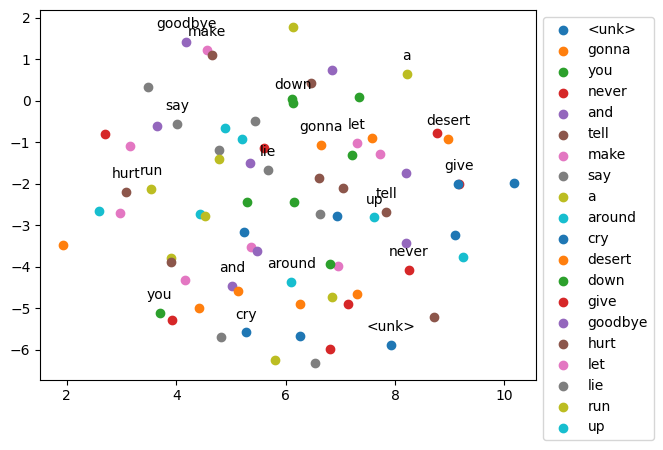

In [40]:
X = model_4.embeddings.weight.cpu().detach().numpy()
tsne = TSNE(n_components=2, random_state=42)
X_2d = tsne.fit_transform(X)

labels = []

for j in range(len(X_2d)):
    if j < 20:
        plt.scatter(X_2d[j, 0], X_2d[j, 1], label=index_to_token[j])
        labels.append(index_to_token[j])
        # Add words as annotations
        plt.annotate(index_to_token[j],
                     (X_2d[j, 0], X_2d[j, 1]),
                     textcoords="offset points",
                     xytext=(0, 10),
                     ha='center')
    else:
        plt.scatter(X_2d[j, 0], X_2d[j, 1])

plt.legend(labels, loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

In [41]:
CONTEXT_SIZE=8
model_8 = NGramLanguageModeler(len(vocab), EMBEDDING_DIM, CONTEXT_SIZE).to(device)
optimizer = optim.SGD(model_8.parameters(), lr=0.01)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 1.0, gamma=0.1)
my_loss=train(dataloader,model_8,song)

save_path = '8gram.pth'
torch.save(model_8.state_dict(), save_path)

my_loss_list.append(my_loss)

  8%|▊         | 8/100 [00:00<00:01, 72.73it/s]

Generated Song:


Never gonna tell a lie and hurt you shy long <unk> <unk> you <unk> <unk> <unk> <unk> <unk> make you <unk> inside <unk> <unk> <unk> <unk> long <unk> shy <unk> <unk> give <unk> <unk> <unk> <unk> you you <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> give <unk> <unk> <unk> <unk> <unk> <unk> tell you <unk> <unk> <unk> <unk> tell you <unk> <unk> <unk> <unk> tell you <unk> <unk> <unk> <unk> <unk> <unk> <unk> you <unk> give <unk> <unk> tell you <unk> <unk> <unk> <unk> you full tell <unk> <unk> shy long <unk> how you guy you <unk> <unk> you im <unk> <unk> <unk> <unk> <unk> <unk>
Generated Song:


Never gonna make you cry never never <unk> give you <unk> never <unk> the <unk> make you <unk> <unk> <unk> it <unk> <unk> im thinking <unk> <unk> <unk> give you <unk> <unk> <unk> <unk> you <unk> <unk> <unk> <unk> im <unk> im feeling <unk> <unk> <unk> <unk> <unk> give <unk> <unk> give you <unk> never <unk> <unk> give you <unk> never <unk> <unk> give you <unk> never <unk> tell n

 32%|███▏      | 32/100 [00:00<00:00, 74.50it/s]

Generated Song:


Never gonna run around and desert you never never <unk> strangers to cry never <unk> the rules make you <unk> <unk> play it <unk> <unk> im thinking me to <unk> im im <unk> <unk> <unk> guy i <unk> <unk> <unk> <unk> it <unk> im feeling <unk> <unk> <unk> up <unk> im <unk> <unk> give you up never <unk> <unk> give you cry never <unk> <unk> run around <unk> never <unk> tell a <unk> make you cry never <unk> <unk> give you up never <unk> tell a lie never <unk> tell never never <unk> other for so long <unk> <unk> <unk> tell <unk> <unk> too shy to say
Generated Song:


Never gonna give you up never never <unk> strangers to so never <unk> the rules make to <unk> <unk> play it <unk> <unk> im thinking me to <unk> im i <unk> <unk> <unk> guy i <unk> <unk> <unk> <unk> it <unk> im feeling <unk> <unk> <unk> up <unk> im <unk> <unk> give you up never <unk> <unk> give you cry never <unk> <unk> run around up never <unk> tell a <unk> make you cry never <unk> <unk> give you up never <unk> te

 48%|████▊     | 48/100 [00:00<00:00, 74.44it/s]

...

 72%|███████▏  | 72/100 [00:00<00:00, 75.45it/s]

Generated Song:


Never gonna say goodbye never never <unk> strangers to so never <unk> the rules make to <unk> <unk> play it and <unk> im thinking me to <unk> im i <unk> <unk> <unk> guy i <unk> <unk> <unk> <unk> it <unk> im feeling <unk> <unk> <unk> long <unk> im <unk> <unk> give you up never <unk> <unk> give you cry never <unk> <unk> run around up never <unk> tell a <unk> make you cry never <unk> <unk> give you up never <unk> tell a lie never <unk> tell never never tell other for so long <unk> <unk> <unk> im <unk> <unk> too shy to say
Generated Song:


Never gonna let you down never never <unk> strangers to so never <unk> the rules make to <unk> <unk> play it and <unk> im thinking me to <unk> im i <unk> <unk> <unk> guy i <unk> <unk> <unk> <unk> it <unk> im feeling <unk> <unk> <unk> long <unk> im <unk> <unk> give you up never <unk> <unk> give you cry never <unk> <unk> run around up never <unk> tell a <unk> make you cry never <unk> <unk> give you up never <unk> tell a lie never <unk> t

 88%|████████▊ | 88/100 [00:01<00:00, 76.17it/s]

Generated Song:


Never gonna tell a lie and hurt you never never tell strangers to so never <unk> the rules make to <unk> <unk> play it and <unk> im thinking me to <unk> im i <unk> <unk> <unk> guy i <unk> <unk> <unk> <unk> it <unk> im feeling <unk> <unk> <unk> long <unk> im <unk> <unk> give you up never <unk> <unk> give you cry never <unk> <unk> run around up never <unk> tell a <unk> make you cry never <unk> <unk> give you up never <unk> tell a lie never <unk> tell never never tell other for so long <unk> <unk> <unk> im <unk> <unk> too shy to say
Generated Song:


Never gonna say goodbye never never tell strangers to so never <unk> the rules make to <unk> <unk> play it and <unk> im thinking me to <unk> im i <unk> <unk> <unk> guy i <unk> <unk> <unk> <unk> it <unk> im feeling <unk> <unk> <unk> up <unk> im <unk> <unk> give you up never <unk> <unk> give you cry never <unk> <unk> run around up never <unk> tell a <unk> make you cry never <unk> <unk> run you up never <unk> tell a lie never <

100%|██████████| 100/100 [00:01<00:00, 75.30it/s]


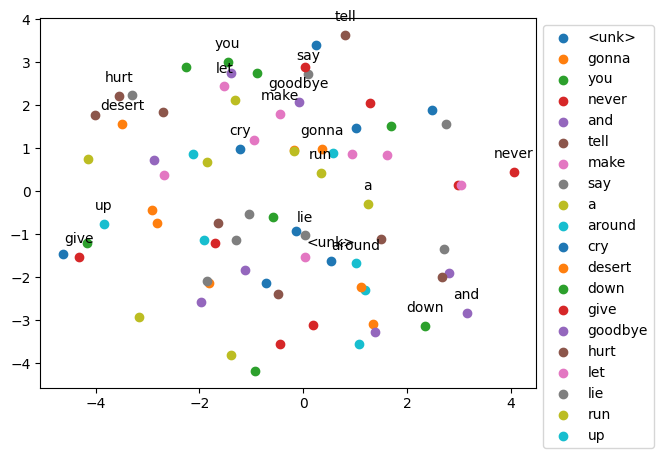

In [42]:
X = model_8.embeddings.weight.cpu().detach().numpy()
tsne = TSNE(n_components=2, random_state=42)
X_2d = tsne.fit_transform(X)

labels = []

for j in range(len(X_2d)):
    if j < 20:
        plt.scatter(X_2d[j, 0], X_2d[j, 1], label=index_to_token[j])
        labels.append(index_to_token[j])
        # Add words as annotations
        plt.annotate(index_to_token[j],
                     (X_2d[j, 0], X_2d[j, 1]),
                     textcoords="offset points",
                     xytext=(0, 10),
                     ha='center')
    else:
        plt.scatter(X_2d[j, 0], X_2d[j, 1])

plt.legend(labels, loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

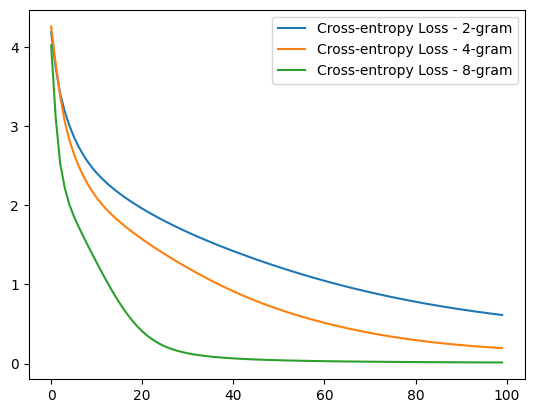

In [43]:
for (my_loss, model_name)in zip(my_loss_list,["2-gram","4-gram","8-gram"]):
    plt.plot(my_loss,label="Cross-entropy Loss - {}".format(model_name))
    plt.legend()

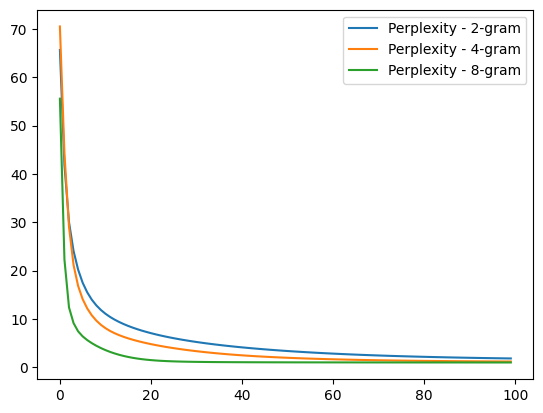

In [44]:
for (my_loss, model_name)in zip(my_loss_list,["2-gram","4-gram","8-gram"]):
    # Calculate perplexity using the loss
    perplexity = np.exp(my_loss)
    plt.plot(perplexity,label="Perplexity - {}".format(model_name))
    plt.legend()

In [45]:
nursery_rhymes = """
Little Miss Muffet
Sat on a tuffet,
Eating her curds and whey;
Along came a spider
Who sat down beside her
And frightened Miss Muffet away.

Twinkle, twinkle, little star,
How I wonder what you are!
Up above the world so high,
Like a diamond in the sky.

Baa, baa, black sheep,
Have you any wool?
Yes sir, yes sir,
Three bags full.

Jack and Jill went up the hill
To fetch a pail of water.
Jack fell down and broke his crown,
And Jill came tumbling after.

Hickory dickory dock,
The mouse ran up the clock.
The clock struck one,
The mouse ran down,
Hickory dickory dock.

Humpty Dumpty sat on a wall,
Humpty Dumpty had a great fall.
All the king's horses and all the king's men
Couldn't put Humpty together again.

Mary had a little lamb,
Its fleece was white as snow;
And everywhere that Mary went,
The lamb was sure to go.

Old MacDonald had a farm,
E-I-E-I-O,
And on his farm he had a cow,
E-I-E-I-O.

Itsy Bitsy Spider climbed up the waterspout.
Down came the rain and washed the spider out.
Out came the sun and dried up all the rain,
And the Itsy Bitsy Spider climbed up the spout again.

The wheels on the bus go round and round,
Round and round,
Round and round.
The wheels on the bus go round and round,
All through the town.

"""

In [46]:
# Define the value of N for N-grams (context size)
N = 2  

# Preprocess the text (e.g., nursery rhymes) to tokenize and clean it
tokens = preprocess(nursery_rhymes)  # Use the preprocess function to tokenize the text

# Generate N-grams using the `genngrams` function
ngrams = genngrams(tokens)  

# Extract the first context-target pair from the list of N-grams
context, target = ngrams[0]  

In [47]:
# Tokenize text and create vocabulary
vocab = tokenizetext(nursery_rhymes)  


# Define embedding dimensions and create layers
embedding_dim = 20  # Each word will be represented as a 20-dimensional vector
linear = nn.Linear(embedding_dim * CONTEXT_SIZE, 128)  


# Generate embeddings using the custom embedding function
embeddings = genembedding(vocab)  


# Convert context words into embeddings
my_embeddings = embeddings(torch.tensor(vocab(context)))  


# Reshape embeddings to match the input shape required by the linear layer
my_embeddings = my_embeddings.reshape(1, -1)  


# Pass embeddings through the linear layer
output = linear(my_embeddings)  


# Print output shape for verification
print("Output shape:", output.shape)  

Output shape: torch.Size([1, 128])


In [48]:
# Define constants for training
CONTEXT_SIZE = 3  # The number of words in the context window
BATCH_SIZE = 10   # The number of samples per batch
EMBEDDING_DIM = 10  # The dimension of the word embeddings

# Compute padding to ensure the number of tokens is evenly divisible by the batch size
Padding = BATCH_SIZE - len(tokens) % BATCH_SIZE  


tokens_pad = tokens + tokens[0:Padding]  


# Define device (CPU/GPU) for computation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  


# Create DataLoader for batch processing
dataloader = DataLoader(
    tokens_pad, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch
)  


# Print length of total tokens after padding
print(f"Total tokens (after padding): {len(tokens_pad)}")

Total tokens (after padding): 240


In [49]:
# Define context size for N-gram modeling
CONTEXT_SIZE = 2  # Number of previous words used as context for predicting the next word

# Define the loss function
criterion = torch.nn.CrossEntropyLoss()  

# Initialize the N-gram language model
model3 = NGramLanguageModeler(len(vocab), EMBEDDING_DIM, CONTEXT_SIZE).to(device)  


# Define the optimizer (Stochastic Gradient Descent)
optimizer = optim.SGD(model3.parameters(), lr=0.01)  

# Implement Learning Rate Scheduling
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.1)  

# Train the model and track loss history
loss_history = train(dataloader, model3, nursery_rhymes)  


# Output expected behavior
print(f"Training started with {len(vocab)} words in vocabulary.")
print(f"Optimizer: {optimizer}")
print(f"Learning rate scheduler: {scheduler}")

 21%|██        | 21/100 [00:00<00:00, 97.40it/s]

Generated Song:


 after away beside bags go any world away diamond away after and everywhere the couldn away after wonder and all up away baa any and bags away beside beside down beside how a of go away fall wonder and away away tuffet of away and put away miss sheep itsy fell after the away away a washed lamb after away after wool after fleece beside everywhere horses washed a a wool away yes i fell any like beside the away go all one pail and horses couldn all away away away after after and how hickory a washed hickory washed
Generated Song:


Its fleece was white as snow; the and the the and the and the the the the and the the the and the the and the the the and the and the the and and and the and the the the the the the the the the and the the and the the the the the the the the the the the the the the and the the the and the and the the the the the the the and the the the the the the and the and and and the the the the the the and the and the the the the the the
Generated Song:



 43%|████▎     | 43/100 [00:00<00:00, 100.38it/s]

Generated Song:


Round and round, the and and the on a the the the a the round the the the and the the and a the and round the and the the and and and the on the a the the up the the the and and the the and the round the and the and and the a the up the the the and the and the and and round the the the the the and the and round the the and the and and the round and round the the and the and the and the and up the the the the the
Generated Song:


Humpty Dumpty had a great fall. the and and the on a the round the a the round round the the and up the on a the and round the and the the and and and a on the a the and up the the the and and a the and the round the and and round and the a the up the sir the and the and the round and round the the the the the a the and round the the round the and round and round and round the the and a and the humpty the and up the the the the the
Generated Song:


 the and and the on a spider round the and the round round the the and up the on a the and rou

 76%|███████▌  | 76/100 [00:00<00:00, 101.09it/s]

Generated Song:


All the king's horses and all the king's men the and muffet the on a farm <unk> a and the round round the a and up the on a the and round the muffet the the and and and humpty on the a the are up the the the and and a the and humpty round the on baa round up the a any up a sir the and the and full round and round the the the the the a the and round the jack round the and round round round and round the the and a dickory dock humpty the ran up the the the the the
Generated Song:


Hickory dickory dock. the and muffet sat on a farm eating a and the round round came a and up the on a the and round the muffet sat the and and and humpty on the a you are up the the the and and a the and humpty round the on baa round up the a any up yes sir the and the and full round and round the the the the the a the jack round the jack round the and round round round and jill the the and a dickory dock humpty the ran up the the the bus the
Generated Song:


Humpty Dumpty sat on a wall, th

100%|██████████| 100/100 [00:01<00:00, 99.01it/s]

Generated Song:


 the miss muffet sat on a farm eating her and the round round came a and up the down beside the and round miss muffet sat twinkle and and and humpty on the a you are up the the the and and a the jack humpty the the baa baa baa came the you any wool yes sir yes sir yes and full jack and jill came the the the the a the jack of water jack round down and jill round round and jill came the and a dickory dock humpty mouse ran up the the the clock the
Training started with 127 words in vocabulary.
Optimizer: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    initial_lr: 0.01
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)
Learning rate scheduler: <torch.optim.lr_scheduler.StepLR object at 0x0000029B4A681580>


In [50]:
# Select a random line from the nursery rhymes dataset
selected_line = pickrandomline(nursery_rhymes)  


# Generate a new rhyme using the trained language model
generated_rhyme = write_song(model3, selected_line)  


# Print the generated rhyme
print(generated_rhyme) 

 little miss muffet sat on a farm eating her and the jill round came a spider of the down beside the and frightened miss muffet sat twinkle and little and humpty on the a you are up the the the and and a dickory jack humpty the the baa baa baa came the you any wool yes sir yes sir yes and full jack and jill came the the the the a the jack of water jack fell down and jill round crown and jill came the and hickory dickory dock humpty mouse ran up the the the clock the
